## Loading and Visualizing an RGB Image of an Endangered Animal

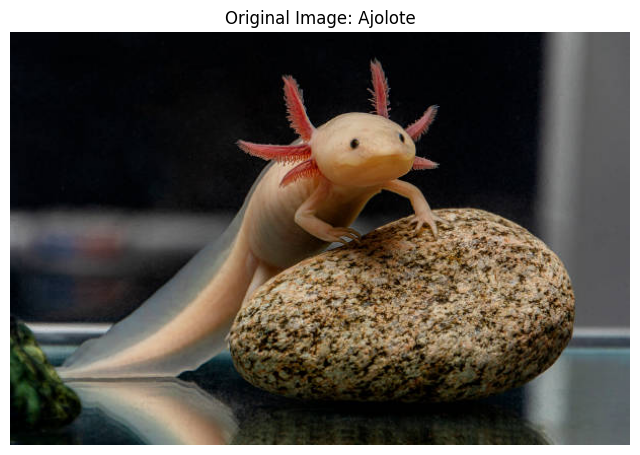

Original image loaded and displayed successfully.


In [ ]:
import cv2
import matplotlib.pyplot as plt

# Load the image
image_path = '/content/ajolote.jpg'
original_image_bgr = cv2.imread(image_path)

# Check if image was loaded successfully
if original_image_bgr is None:
    print(f"Error: Could not load image from {image_path}")
else:
    # Convert BGR to RGB
    original_image_rgb = cv2.cvtColor(original_image_bgr, cv2.COLOR_BGR2RGB)

    # Display the image
    plt.figure(figsize=(8, 8))
    plt.imshow(original_image_rgb)
    plt.title('Original Image: Ajolote')
    plt.axis('off') # Hide axes for a cleaner look
    plt.show()

    print("Original image loaded and displayed successfully.")

## Basic Filters
Apply the following filters to the image:

- Smoothing / Blurring
- Edge Enhancement



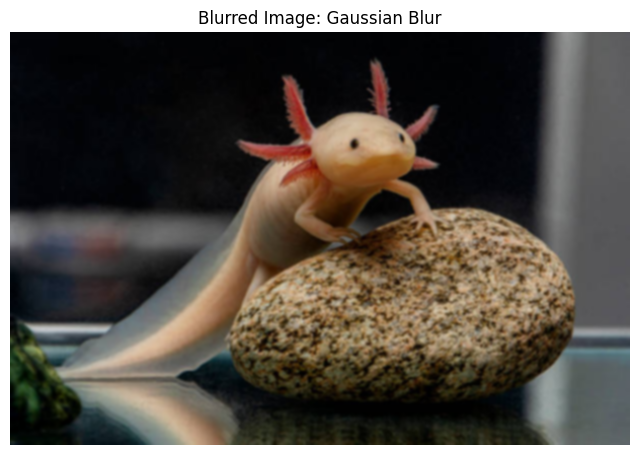

Visual Effect (Blurred Image): The image appears smoother and details are softened, reducing noise and sharp edges. This is typical for a blurring filter.


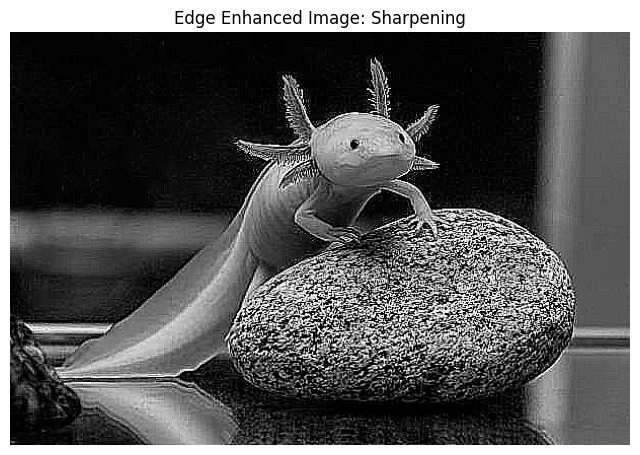

Visual Effect (Sharpened Image): The image's edges and fine details are more pronounced and defined, making the image appear 'sharper'. This effect is achieved by increasing the contrast around edges.


In [ ]:
import numpy as np

# 1. Apply Gaussian blur filter
blurred_image = cv2.GaussianBlur(original_image_rgb, (5, 5), 0)

# 2. Display the blurred image
plt.figure(figsize=(8, 8))
plt.imshow(blurred_image)
plt.title('Blurred Image: Gaussian Blur')
plt.axis('off')
plt.show()
print("Visual Effect (Blurred Image): The image appears smoother and details are softened, reducing noise and sharp edges.")

# 3. Convert original_image_rgb to grayscale
gray_image = cv2.cvtColor(original_image_rgb, cv2.COLOR_RGB2GRAY)

# 4. Define a sharpening kernel
sharpening_kernel = np.array([[-1, -1, -1],
                              [-1,  9, -1],
                              [-1, -1, -1]])

# 5. Apply the sharpening kernel to the grayscale image
sharpened_image = cv2.filter2D(gray_image, -1, sharpening_kernel)

# 6. Display the sharpened image
plt.figure(figsize=(8, 8))
plt.imshow(sharpened_image, cmap='gray')
plt.title('Edge Enhanced Image: Sharpening')
plt.axis('off')
plt.show()
print("Visual Effect (Sharpened Image): The image's edges and fine details are more pronounced and defined, making the image appear 'sharper'. This effect is achieved by increasing the contrast around edges.")

## Visualizing Color Channels

Separate the original image into its three channels (R, G, B). Display each channel separately in grayscale within a single figure and briefly explain which structures appear lighter or darker in each channel and why.

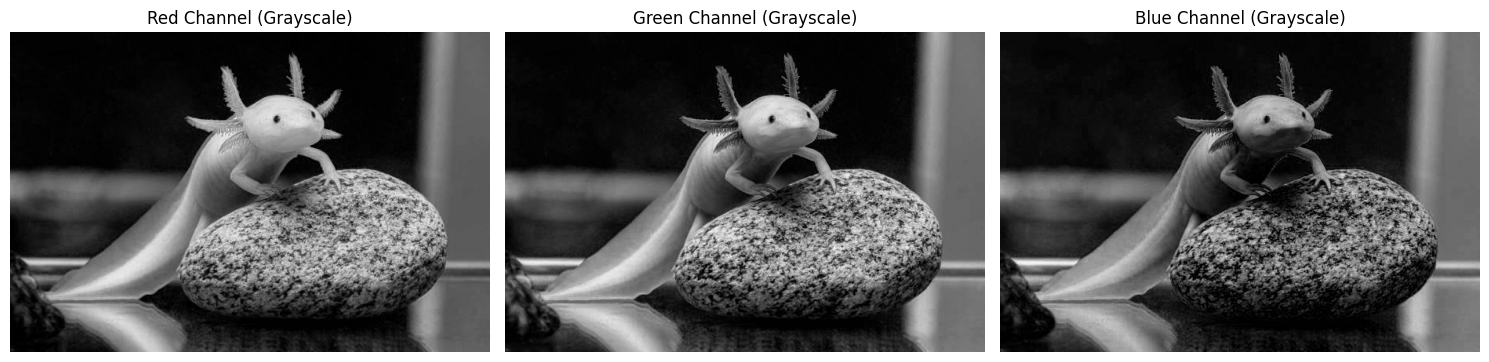

In [ ]:
import matplotlib.pyplot as plt

# Split the original_image_rgb into its individual R, G, B channels
r_channel = original_image_rgb[:, :, 0]
g_channel = original_image_rgb[:, :, 1]
b_channel = original_image_rgb[:, :, 2]

# Create a figure with subplots to display all three channels
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(r_channel, cmap='gray')
plt.title('Red Channel (Grayscale)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(g_channel, cmap='gray')
plt.title('Green Channel (Grayscale)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(b_channel, cmap='gray')
plt.title('Blue Channel (Grayscale)')
plt.axis('off')

plt.tight_layout()
plt.show()

### Explanation of Color Channels (Grayscale View)

When viewing individual color channels as grayscale images, the brightness of a pixel in that channel corresponds to the intensity of that specific color component in the original image. Lighter areas indicate a stronger presence of that color, while darker areas indicate a weaker presence.

*   **Red Channel (Grayscale)**:
    In the red channel, areas of the original image that contain more red appear brighter. If the ajolote has reddish or pinkish tones, these parts will likely be lighter. Any green or blue elements in the original image will appear darker in this channel.

*   **Green Channel (Grayscale)**:
    Similarly, in the green channel, parts of the ajolote or its surroundings that are rich in green will be brighter. For example, if there's any vegetation or algae around the ajolote, or if the ajolote itself has greenish pigmentation, these regions would stand out as lighter areas. Red and blue components would appear darker.

*   **Blue Channel (Grayscale)**:
    The blue channel highlights areas with a strong blue component. Water bodies, skies, or certain aquatic features often show up brighter in the blue channel. If the ajolote's skin has cool undertones or is illuminated by blue light, those areas would be lighter. Red and green elements will appear darker.

## Morphological Operations


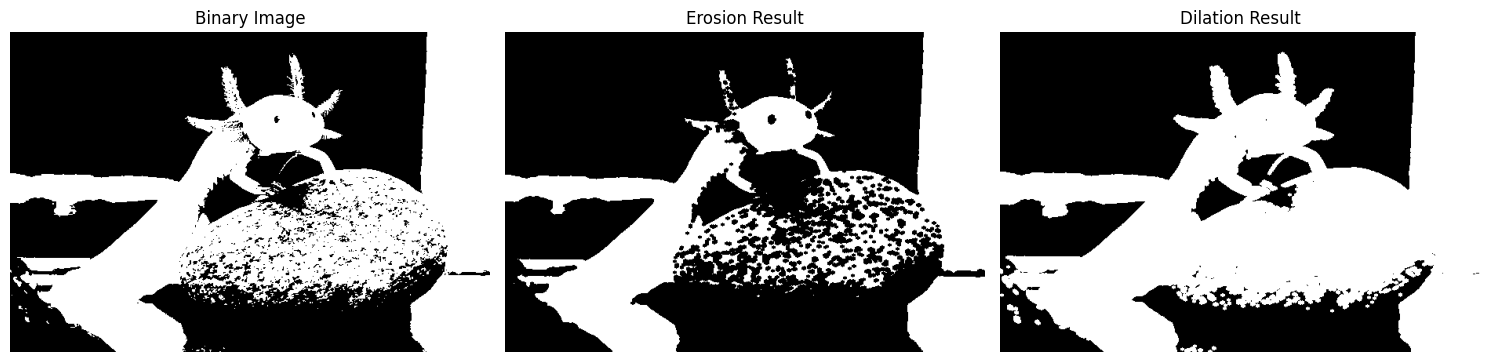

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Convert gray_image to a binary image
# Applying Otsu's thresholding for automatic threshold calculation
ret, binary_image = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 2. Define a kernel for morphological operations
# A 5x5 elliptical kernel is a good general choice
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

# 3. Apply the first morphological operation: Erosion
eroded_image = cv2.erode(binary_image, kernel, iterations=1)

# 4. Apply the second morphological operation: Dilation
dilated_image = cv2.dilate(binary_image, kernel, iterations=1)

# 5. Create a figure with subplots to display the images
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(binary_image, cmap='gray')
plt.title('Binary Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(eroded_image, cmap='gray')
plt.title('Erosion Result')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(dilated_image, cmap='gray')
plt.title('Dilation Result')
plt.axis('off')

plt.tight_layout()
# 6. Display the figure
plt.show()

### Explanation of Morphological Operations

**Erosion Result:**
Erosion is a morphological operation that 'shrinks' or 'thins' binary images. It removes pixels from object boundaries based on the size and shape of the structuring element (kernel). In the Erosion Result image, we observe that the white regions (foreground objects) are smaller compared to the Binary Image. This operation can be useful for removing small unwanted details, separating joined objects, or smoothing object boundaries.

**Dilation Result:**
Dilation is the opposite of erosion; it 'grows' or 'thickens' binary images. It adds pixels to object boundaries, again based on the structuring element. In the Dilation Result image, the white regions (foreground objects) appear larger and more expanded than in the Binary Image. Dilation can be used to fill small holes in objects, connect broken parts of an object, or make objects more prominent.

## Animation

In [22]:
import imageio.v2 as imageio
import os

# 1. Create a list containing original_image_rgb, blurred_image, and sharpened_image_rgb
# sharpened_image_rgb was already created in a previous step by converting sharpened_image (grayscale) to RGB.
frames_comparison = [
    original_image_rgb,
    blurred_image,
    sharpened_image_rgb
]

# 2. Define a file path for the new GIF, ensuring the directory 'gifs' exists.
# The 'gifs' directory was already created in the previous GIF generation step.
gifs_dir = 'gifs'
os.makedirs(gifs_dir, exist_ok=True) # Ensure directory exists (though it should already)
gif_comparison_path = os.path.join(gifs_dir, 'ajolote_filters_comparison.gif')

# 3. Use imageio.mimsave to save the list of images as a GIF
imageio.mimsave(gif_comparison_path, frames_comparison, duration=2, loop=0) # 2 seconds per frame, loop indefinitely

print(f"Filters comparison GIF saved to: {gif_comparison_path}")

Filters comparison GIF saved to: gifs/ajolote_filters_comparison.gif


In [23]:
import imageio.v2 as imageio
import os

# 1. Create a list containing binary_image_rgb, eroded_image_rgb, and dilated_image_rgb
# These RGB converted images were already created in a previous step.
frames_morphological = [
    binary_image_rgb,
    eroded_image_rgb,
    dilated_image_rgb
]

# 2. Define a file path for the new GIF, ensuring the directory 'gifs' exists.
gifs_dir = 'gifs'
os.makedirs(gifs_dir, exist_ok=True) # Ensure directory exists (though it should already)
gif_morphological_path = os.path.join(gifs_dir, 'ajolote_morphological_comparison.gif')

# 3. Use imageio.mimsave to save the list of images as a GIF
imageio.mimsave(gif_morphological_path, frames_morphological, duration=2, loop=0) # 2 seconds per frame, loop indefinitely

print(f"Morphological operations comparison GIF saved to: {gif_morphological_path}")

Morphological operations comparison GIF saved to: gifs/ajolote_morphological_comparison.gif


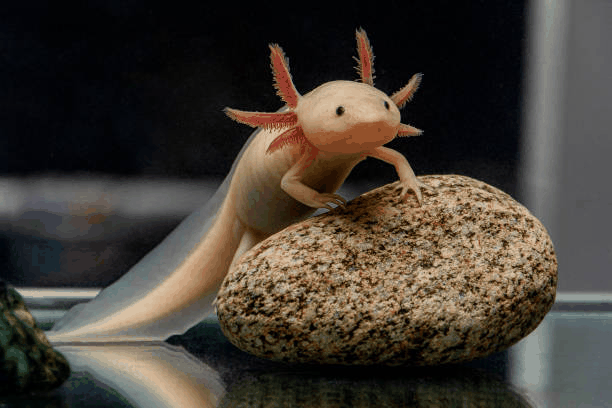

Displayed: gifs/ajolote_filters_comparison.gif


In [24]:
from IPython.display import Image

# Display the filters comparison GIF
filters_gif = Image(filename=gif_comparison_path)
display(filters_gif)

print(f'Displayed: {gif_comparison_path}')

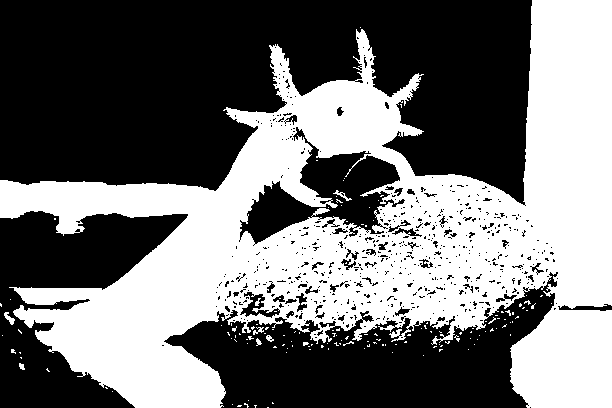

Displayed: gifs/ajolote_morphological_comparison.gif


In [25]:
from IPython.display import Image

# Display the morphological operations comparison GIF
morphological_gif = Image(filename=gif_morphological_path)
display(morphological_gif)

print(f'Displayed: {gif_morphological_path}')